<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/statistics_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


In [99]:
df=pd.read_csv("bhp.csv")

In [100]:
df.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250


In [101]:
df.min()

,0
location,1st Block Jayanagar
size,1 BHK
total_sqft,1.0
bath,1.0
price,8.0
bhk,1
price_per_sqft,267


In [102]:
df.max()

,0
location,other
size,9 Bedroom
total_sqft,52272.0
bath,40.0
price,3600.0
bhk,43
price_per_sqft,12000000


In [103]:
avg=df['price_per_sqft'].mean()
avg

np.float64(7920.336742424242)

In [104]:
print(avg)

7920.336742424242


In [105]:
df['price_per_sqft'].describe()

,price_per_sqft
count,1.320000e+04
mean,7.920337e+03
std,1.067272e+05
min,2.670000e+02
25%,4.267000e+03
50%,5.438000e+03
75%,7.317000e+03
max,1.200000e+07


In [106]:
l_p,h_p=df['price_per_sqft'].quantile([0.001,0.999])
l_p,h_p

(1366.184, 50959.36200000098)

In [107]:
outliers=df[(df['price_per_sqft']<l_p) | (df['price_per_sqft']>h_p)]
outliers

,location,size,total_sqft,bath,price,bhk,price_per_sqft
345,other,3 Bedroom,11.0,3.0,74.0,3,672727
665,Yelahanka,3 BHK,35000.0,3.0,130.0,3,371
798,other,4 Bedroom,10961.0,4.0,80.0,4,729
1005,other,1 BHK,15.0,1.0,30.0,1,200000
1106,other,5 Bedroom,24.0,2.0,150.0,5,625000
1867,other,3 Bedroom,52272.0,2.0,140.0,3,267
2392,other,4 Bedroom,2000.0,3.0,25.0,4,1250
3934,other,1 BHK,1500.0,1.0,19.5,1,1300
4044,Sarjapur Road,4 Bedroom,1.0,4.0,120.0,4,12000000
4924,other,7 BHK,5.0,7.0,115.0,7,2300000


In [108]:
outliers.shape

(28, 7)

In [109]:
df.shape

(13200, 7)

In [110]:
df_no_outlier=df[(df['price_per_sqft']>l_p) & (df['price_per_sqft']<h_p)]
df_no_outlier

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250
...,...,...,...,...,...,...,...
13195,Whitefield,5 Bedroom,3453.0,4.0,231.00,5,6689
13196,other,4 BHK,3600.0,5.0,400.00,4,11111
13197,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,60.00,2,5258
13198,Padmanabhanagar,4 BHK,4689.0,4.0,488.00,4,10407


In [111]:
df.shape


(13200, 7)

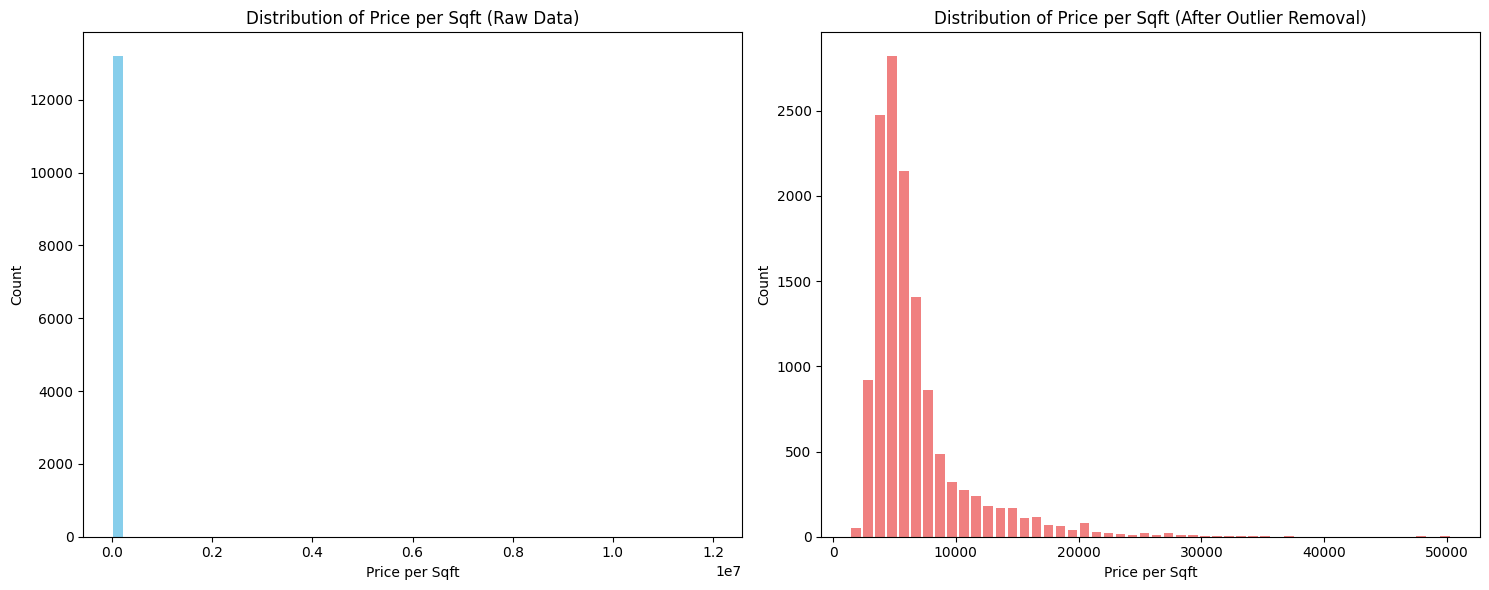

In [112]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.hist(df['price_per_sqft'], bins=50, rwidth=0.8, color='skyblue')
plt.xlabel('Price per Sqft')
plt.ylabel('Count')
plt.title('Distribution of Price per Sqft (Raw Data)')

plt.subplot(1, 2, 2)
plt.hist(df_no_outlier['price_per_sqft'], bins=50, rwidth=0.8, color='lightcoral')
plt.xlabel('Price per Sqft')
plt.ylabel('Count')
plt.title('Distribution of Price per Sqft (After Outlier Removal)')

plt.tight_layout()
plt.show()

### Outlier Removal using Standard Deviation Method

The standard deviation method for outlier detection identifies data points that are significantly far from the mean, typically defined by a certain number of standard deviations (e.g., 3 or 4 standard deviations). Data points outside this range are considered outliers.

In [113]:
mean_price_per_sqft = df['price_per_sqft'].mean()
std_price_per_sqft = df['price_per_sqft'].std()

print(f"Mean of price_per_sqft: {mean_price_per_sqft:.2f}")
print(f"Standard deviation of price_per_sqft: {std_price_per_sqft:.2f}")

Mean of price_per_sqft: 7920.34
Standard deviation of price_per_sqft: 106727.16


In [114]:
# Define the lower and upper bounds using 4 standard deviations
lower_bound_std = mean_price_per_sqft - (4 * std_price_per_sqft)
upper_bound_std = mean_price_per_sqft + (4 * std_price_per_sqft)

print(f"Lower bound (Mean - 4*StdDev): {lower_bound_std:.2f}")
print(f"Upper bound (Mean + 4*StdDev): {upper_bound_std:.2f}")

Lower bound (Mean - 4*StdDev): -418988.30
Upper bound (Mean + 4*StdDev): 434828.98


In [115]:
# Filter the DataFrame to remove outliers based on the 4 standard deviation method
df_std_no_outlier = df[(df['price_per_sqft'] > lower_bound_std) & (df['price_per_sqft'] < upper_bound_std)]

print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame shape after 4-std outlier removal: {df_std_no_outlier.shape}")

display(df_std_no_outlier.head())

Original DataFrame shape: (13200, 7)
DataFrame shape after 4-std outlier removal: (13196, 7)


,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250


Now, let's visualize the distribution of `price_per_sqft` after removing outliers using the 4 standard deviation method, and compare it with the original distribution.

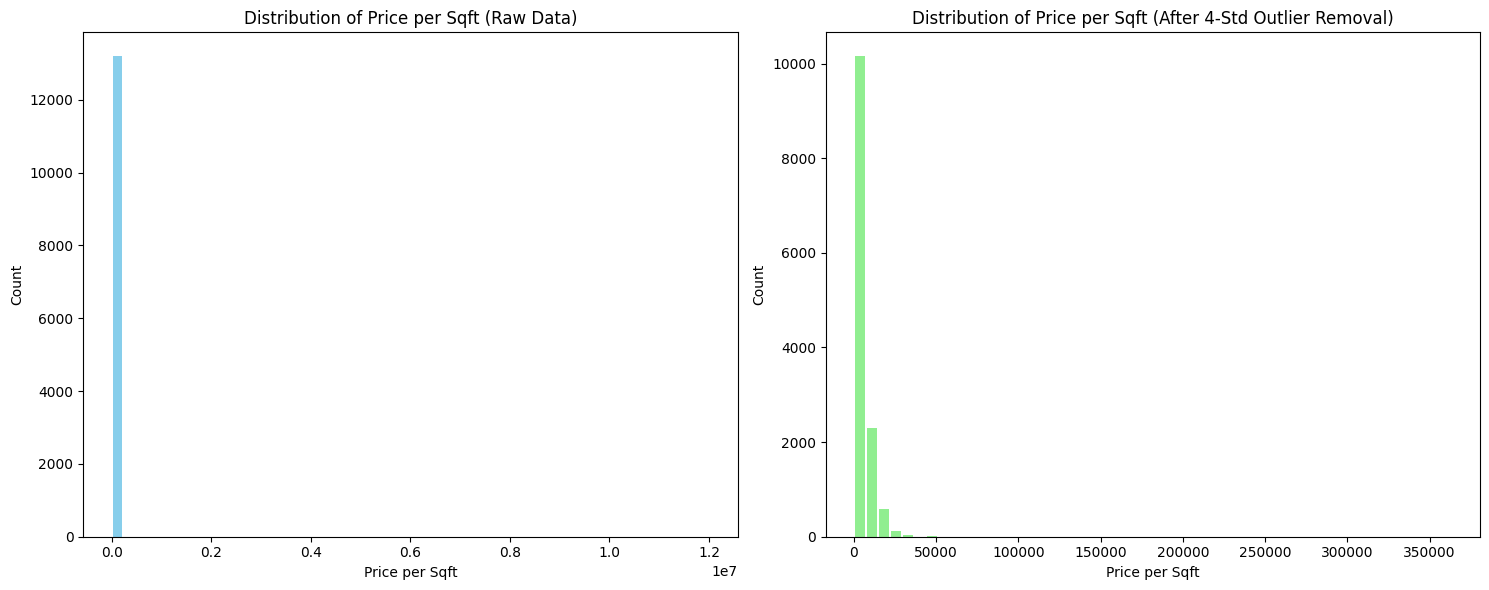

In [116]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.hist(df['price_per_sqft'], bins=50, rwidth=0.8, color='skyblue')
plt.xlabel('Price per Sqft')
plt.ylabel('Count')
plt.title('Distribution of Price per Sqft (Raw Data)')

plt.subplot(1, 2, 2)
plt.hist(df_std_no_outlier['price_per_sqft'], bins=50, rwidth=0.8, color='lightgreen')
plt.xlabel('Price per Sqft')
plt.ylabel('Count')
plt.title('Distribution of Price per Sqft (After 4-Std Outlier Removal)')

plt.tight_layout()
plt.show()

In [117]:
df['z_score']=(df['price_per_sqft']-df['price_per_sqft'].mean())/df['price_per_sqft'].std()
df['z_score']

,z_score
0,-0.039553
1,-0.030970
2,-0.033875
3,-0.015697
4,-0.034390
...,...
13195,-0.011537
13196,0.029896
13197,-0.024945
13198,0.023299


In [118]:
z_score.min()
z_score.max()

11999999.92578893

In [119]:
df.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft,z_score
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699,-0.039553
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615,-0.030970
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305,-0.033875
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245,-0.015697
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250,-0.034390


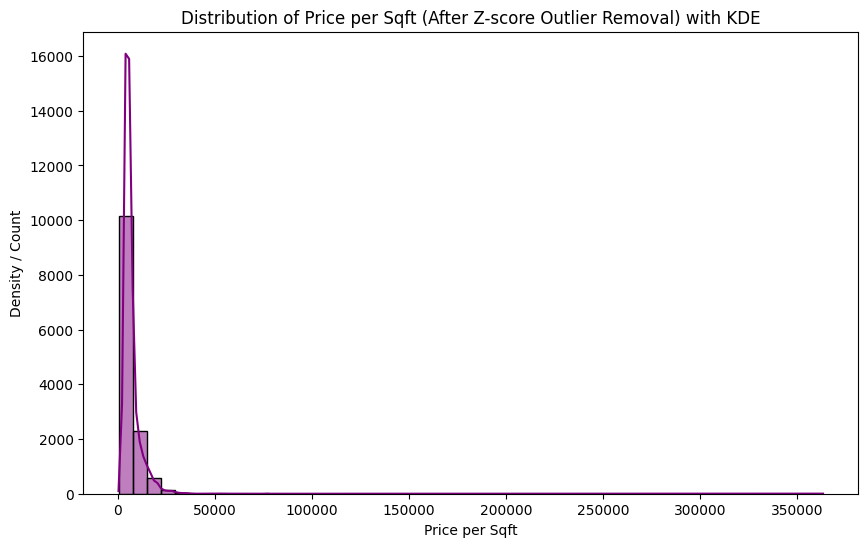

In [120]:
df_no_outlier=df[(df['z_score']>-4) & (df['z_score']<4)]

plt.figure(figsize=(10, 6))
sns.histplot(df_no_outlier['price_per_sqft'], bins=50, kde=True, color='purple')
plt.title('Distribution of Price per Sqft (After Z-score Outlier Removal) with KDE')
plt.xlabel('Price per Sqft')
plt.ylabel('Density / Count')
plt.show()

In [121]:
df_no_outlier.shape

(13196, 8)

## Now Removing the Outliers from the wine.csv data set


In [124]:
df=pd.read_csv('wine_data.csv')
df


,1,14.23,1.71,2.43,15.6,127,2.8,3.06,.28,2.29,5.64,1.04,3.92,1065
0,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
2,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
3,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
4,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
173,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
174,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
175,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [147]:
df.shape

(178, 15)

In [125]:
column_names = [
    'class',
    'alcohol',
    'malic_acid',
    'ash',
    'alcalinity_of_ash',
    'magnesium',
    'total_phenols',
    'flavanoids',
    'nonflavanoid_phenols',
    'proanthocyanins',
    'color_intensity',
    'hue',
    'od280_od315_of_diluted_wines',
    'proline'
]

df = pd.read_csv('wine_data.csv', header=None, names=column_names)
df.head()

,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315_of_diluted_wines,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [126]:
l_malic, h_malic = df['malic_acid'].quantile([0.001, 0.999])
print(f"Lower bound for malic_acid (0.1th percentile): {l_malic:.3f}")
print(f"Upper bound for malic_acid (99.9th percentile): {h_malic:.3f}")

Lower bound for malic_acid (0.1th percentile): 0.767
Upper bound for malic_acid (99.9th percentile): 5.773


In [129]:
outliers_malic=df[(df['malic_acid']<l_malic) | (df['malic_acid']>h_malic)]
outliers_malic

,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315_of_diluted_wines,proline
113,2,11.41,0.74,2.50,21.0,88,2.48,2.01,0.42,1.44,3.08,1.10,2.31,434
123,2,13.05,5.80,2.13,21.5,86,2.62,2.65,0.30,2.01,2.60,0.73,3.10,380


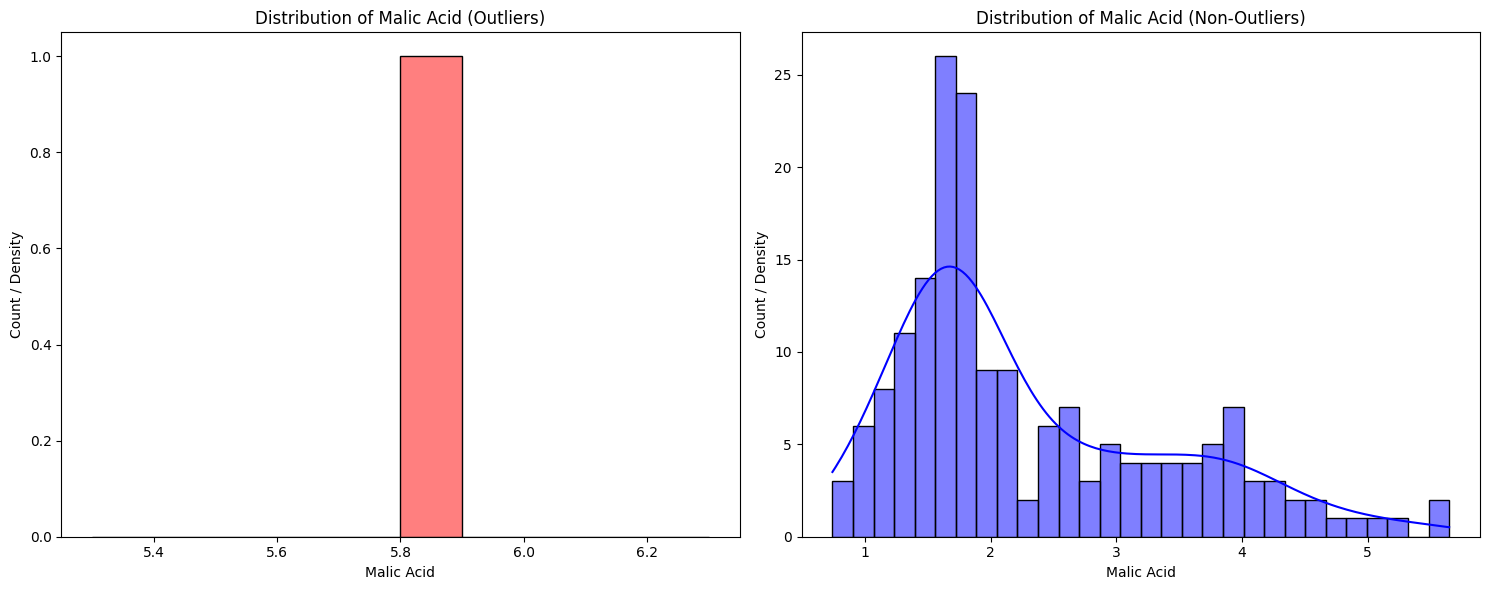

In [149]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(outliers['malic_acid'], bins=10, kde=True, color='red')
plt.title('Distribution of Malic Acid (Outliers)')
plt.xlabel('Malic Acid')
plt.ylabel('Count / Density')

plt.subplot(1, 2, 2)
sns.histplot(non_outliers['malic_acid'], bins=30, kde=True, color='blue')
plt.title('Distribution of Malic Acid (Non-Outliers)')
plt.xlabel('Malic Acid')
plt.ylabel('Count / Density')

plt.tight_layout()
plt.show()

In [148]:
df.describe()

,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315_of_diluted_wines,proline,z_score
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.000000
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,1.000000
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,-1.428952
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,-0.656896
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,-0.421922
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,0.667909
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,3.100446


In [131]:
non_outliers=df[(df['malic_acid']>l_malic)&(df['malic_acid']<h_malic)]
non_outliers

,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315_of_diluted_wines,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [133]:
df.shape

(178, 14)

In [134]:
non_outliers.shape

(176, 14)

In [135]:
mean=df['malic_acid'].mean()
std=df['malic_acid'].std()

In [136]:
h_ml=mean+std
l_ml=mean-std

In [138]:
non_outliers=df[(df['malic_acid']>l_ml)&(df['malic_acid']<h_ml)]
non_outliers

,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315_of_diluted_wines,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.640000,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.380000,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.680000,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.800000,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.320000,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168,3,13.58,2.58,2.69,24.5,105,1.55,0.84,0.39,1.54,8.660000,0.74,1.80,750
170,3,12.20,3.03,2.32,19.0,96,1.25,0.49,0.40,0.73,5.500000,0.66,1.83,510
171,3,12.77,2.39,2.28,19.5,86,1.39,0.51,0.48,0.64,9.899999,0.57,1.63,470
172,3,14.16,2.51,2.48,20.0,91,1.68,0.70,0.44,1.24,9.700000,0.62,1.71,660


In [139]:
non_outliers.shape

(128, 14)

In [141]:
df['z_score']=(df['malic_acid']-df['malic_acid'].mean())/df['malic_acid'].std()
df['z_score']

,z_score
0,-0.560668
1,-0.498009
2,0.021172
3,-0.345835
4,0.227053
...,...
173,2.966176
174,1.408636
175,1.739837
176,0.227053


In [142]:
df

,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315_of_diluted_wines,proline,z_score
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,-0.560668
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,-0.498009
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,0.021172
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,-0.345835
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,0.227053
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,2.966176
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,1.408636
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,1.739837
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,0.227053


In [144]:
threshold=3
outliers=df[df['z_score'].abs()>threshold]
outliers

,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315_of_diluted_wines,proline,z_score
123,2,13.05,5.8,2.13,21.5,86,2.62,2.65,0.3,2.01,2.6,0.73,3.1,380,3.100446


In [146]:
non_outliers=df[df['z_score'].abs()<threshold]
non_outliers

,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315_of_diluted_wines,proline,z_score
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,-0.560668
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,-0.498009
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,0.021172
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,-0.345835
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,0.227053
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,2.966176
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,1.408636
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,1.739837
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,0.227053


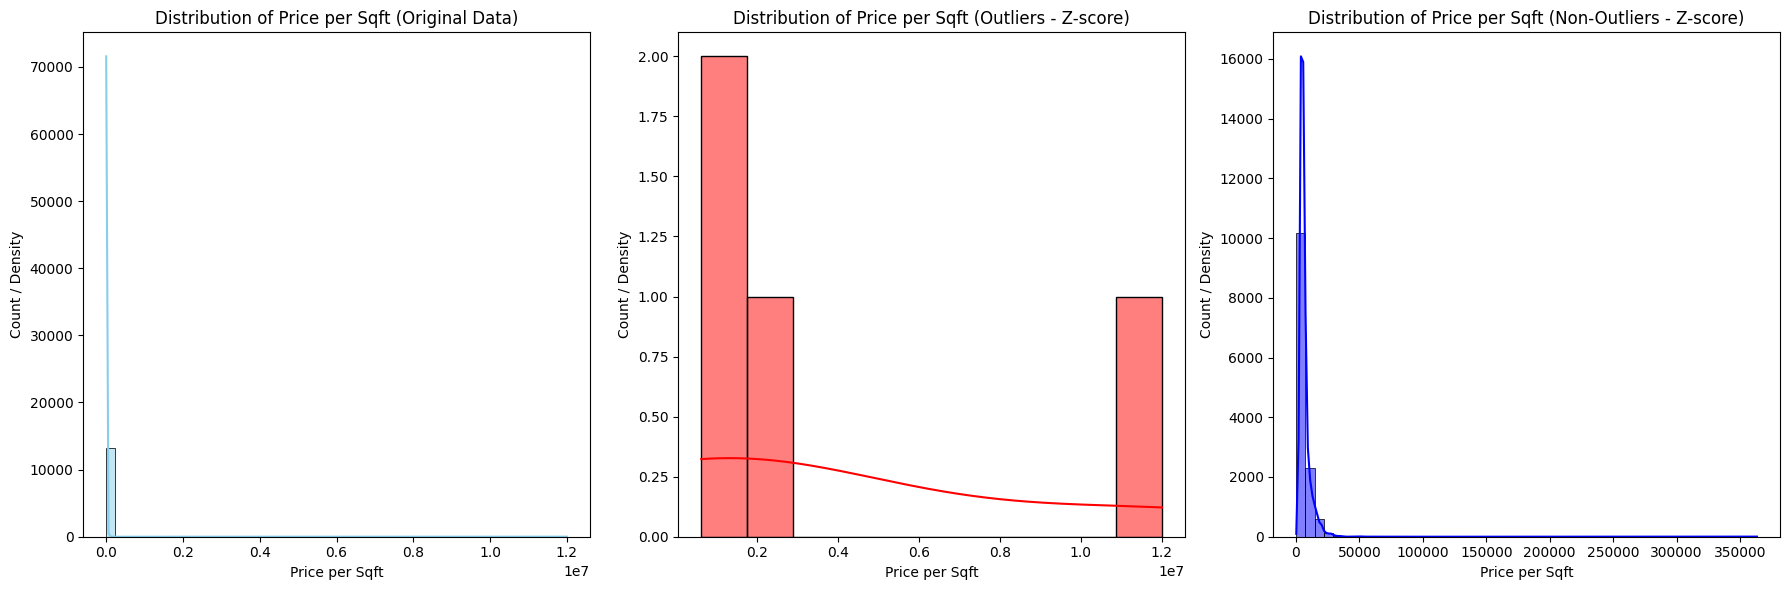

In [152]:
# Create a temporary DataFrame for bhp.csv to re-calculate z_score for price_per_sqft
df_temp_bhp = pd.read_csv("bhp.csv")
df_temp_bhp['z_score_price'] = (df_temp_bhp['price_per_sqft'] - df_temp_bhp['price_per_sqft'].mean()) / df_temp_bhp['price_per_sqft'].std()

# Define outliers for price_per_sqft using Z-score method (absolute Z-score > 4)
outliers_price = df_temp_bhp[df_temp_bhp['z_score_price'].abs() > 4]

# The df_no_outlier from the Z-score method (cell uMuBCt21iLiN) is already available and correctly filtered for bhp.csv

plt.figure(figsize=(18, 6)) # Increased figure size to accommodate three plots

plt.subplot(1, 3, 1) # Changed to 1 row, 3 columns, first plot
sns.histplot(df_temp_bhp['price_per_sqft'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Price per Sqft (Original Data)')
plt.xlabel('Price per Sqft')
plt.ylabel('Count / Density')

plt.subplot(1, 3, 2) # Changed to 1 row, 3 columns, second plot
sns.histplot(outliers_price['price_per_sqft'], bins=10, kde=True, color='red')
plt.title('Distribution of Price per Sqft (Outliers - Z-score)')
plt.xlabel('Price per Sqft')
plt.ylabel('Count / Density')

plt.subplot(1, 3, 3) # Changed to 1 row, 3 columns, third plot
sns.histplot(df_no_outlier['price_per_sqft'], bins=50, kde=True, color='blue')
plt.title('Distribution of Price per Sqft (Non-Outliers - Z-score)')
plt.xlabel('Price per Sqft')
plt.ylabel('Count / Density')

plt.tight_layout()
plt.show()

### Normalization techniques


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [5]:
df=pd.read_csv("wine_data.csv")
df

,1,14.23,1.71,2.43,15.6,127,2.8,3.06,.28,2.29,5.64,1.04,3.92,1065
0,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
2,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
3,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
4,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
173,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
174,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
175,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [6]:
column_names = [
    'class',
    'alcohol',
    'malic_acid',
    'ash',
    'alcalinity_of_ash',
    'magnesium',
    'total_phenols',
    'flavanoids',
    'nonflavanoid_phenols',
    'proanthocyanins',
    'color_intensity',
    'hue',
    'od280_od315_of_diluted_wines',
    'proline'
]

df = pd.read_csv('wine_data.csv', header=None, names=column_names)
df.head()

,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315_of_diluted_wines,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [9]:
from sklearn.model_selection import train_test_split

In [12]:
x_train,x_test,y_train,y_test=train_test_split(df.drop('class',axis=1),df['class'],test_size=0.2,random_state=42)

In [16]:
x_train.shape,x_test.shape

((142, 13), (36, 13))

In [19]:
df['class'].max()
df['class'].min()

1

In [22]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [23]:
x_train_df=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_df=pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [24]:
x_test_df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315_of_diluted_wines,proline
0,0.686842,0.450102,0.641711,0.237113,0.500000,0.593103,0.567511,0.075472,0.392405,0.298401,0.390244,0.765568,0.446809
1,0.836842,0.641548,0.577540,0.427835,0.445652,0.644828,0.487342,0.320755,0.262658,0.310835,0.317073,0.754579,0.631994
2,0.500000,0.391039,0.716578,0.536082,0.282609,0.193103,0.033755,0.754717,0.104430,0.253996,0.235772,0.380952,0.253743
3,0.710526,0.124236,0.716578,0.613402,0.336957,0.696552,0.613924,0.301887,0.620253,0.351687,0.577236,0.527473,0.793538
4,0.352632,0.057026,0.299465,0.463918,0.086957,0.389655,0.350211,0.264151,0.196203,0.261101,0.520325,0.809524,0.182821
5,0.860526,0.209776,0.727273,0.484536,0.543478,0.627586,0.590717,0.377358,0.490506,0.396092,0.479675,0.505495,0.789598
6,0.255263,0.517312,0.342246,0.432990,0.184783,0.351724,0.274262,0.452830,0.458861,-0.040853,0.365854,0.652015,0.225374
7,0.623684,0.615071,0.598930,0.639175,0.347826,0.282759,0.086498,0.566038,0.313291,0.493783,0.178862,0.106227,0.371946
8,0.152632,0.093686,0.716578,0.484536,0.260870,0.606897,0.544304,0.301887,0.655063,0.080817,0.390244,0.728938,0.316785
9,0.613158,0.340122,0.529412,0.484536,0.206522,0.144828,0.033755,0.452830,0.069620,0.342806,0.178862,0.439560,0.395587


In [25]:
x_train_df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315_of_diluted_wines,proline
0,0.871053,0.160896,0.716578,0.742268,0.304348,0.627586,0.204641,0.754717,0.721519,1.000000,0.073171,0.252747,0.301024
1,0.394737,0.940937,0.684492,0.742268,0.282609,0.279310,0.054852,0.943396,0.215190,0.289520,0.276423,0.153846,0.186761
2,0.352632,0.036660,0.395722,0.407216,0.195652,0.875862,0.719409,0.207547,0.484177,0.245115,0.455285,0.549451,0.301024
3,0.644737,0.158859,0.684492,0.613402,0.206522,0.558621,0.160338,0.735849,0.591772,0.888988,0.073171,0.186813,0.269504
4,0.536842,0.124236,0.395722,0.252577,0.304348,0.489655,0.485232,0.283019,0.300633,0.174067,0.569106,0.520147,0.584712
...,...,...,...,...,...,...,...,...,...,...,...,...,...
137,0.744737,0.126273,0.700535,0.742268,0.173913,0.679310,0.531646,0.150943,0.458861,0.145648,0.715447,0.692308,0.104019
138,0.321053,0.171079,0.406417,0.432990,0.108696,0.231034,0.356540,0.452830,0.382911,0.147425,0.422764,0.695971,0.182821
139,0.881579,0.199593,0.545455,0.072165,0.347826,0.800000,0.696203,0.301887,0.803797,0.511545,0.585366,0.633700,1.000000
140,0.436842,0.130346,0.481283,0.520619,0.108696,0.137931,0.236287,0.849057,0.379747,0.116341,0.390244,0.289377,0.171001


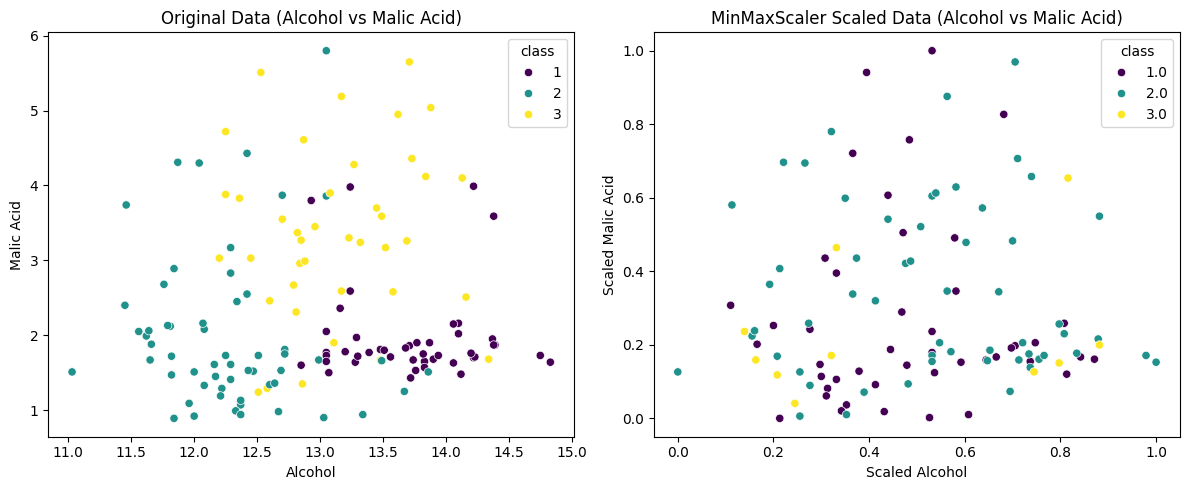

In [26]:
plt.figure(figsize=(12, 5))

# Scatter plot for original data
plt.subplot(1, 2, 1)
sns.scatterplot(x=x_train['alcohol'], y=x_train['malic_acid'], hue=y_train, palette='viridis')
plt.title('Original Data (Alcohol vs Malic Acid)')
plt.xlabel('Alcohol')
plt.ylabel('Malic Acid')

# Scatter plot for scaled data
plt.subplot(1, 2, 2)
sns.scatterplot(x=x_train_df['alcohol'], y=x_train_df['malic_acid'], hue=y_train, palette='viridis')
plt.title('MinMaxScaler Scaled Data (Alcohol vs Malic Acid)')
plt.xlabel('Scaled Alcohol')
plt.ylabel('Scaled Malic Acid')

plt.tight_layout()
plt.show()

In [27]:
x_train_df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315_of_diluted_wines,proline
count,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000
mean,0.512917,0.302143,0.535211,0.457383,0.330909,0.451408,0.350657,0.449110,0.375958,0.294636,0.387301,0.484548,0.360043
std,0.215820,0.232980,0.149314,0.178082,0.159248,0.219902,0.211850,0.242016,0.184701,0.207009,0.190326,0.264520,0.238238
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.342763,0.147658,0.454545,0.340206,0.198370,0.256897,0.165612,0.264151,0.262658,0.131439,0.245935,0.207875,0.176911
50%,0.521053,0.200611,0.534759,0.443299,0.304348,0.458621,0.366034,0.396226,0.359177,0.253996,0.394309,0.551282,0.301024
75%,0.696711,0.457230,0.631016,0.561856,0.402174,0.627586,0.527954,0.641509,0.489715,0.389210,0.520325,0.695971,0.515957
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [31]:
np.round(x_train_df.describe(),1)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315_of_diluted_wines,proline
count,142.0,142.0,142.0,142.0,142.0,142.0,142.0,142.0,142.0,142.0,142.0,142.0,142.0
mean,0.5,0.3,0.5,0.5,0.3,0.5,0.4,0.4,0.4,0.3,0.4,0.5,0.4
std,0.2,0.2,0.1,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.3,0.2
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.3,0.1,0.5,0.3,0.2,0.3,0.2,0.3,0.3,0.1,0.2,0.2,0.2
50%,0.5,0.2,0.5,0.4,0.3,0.5,0.4,0.4,0.4,0.3,0.4,0.6,0.3
75%,0.7,0.5,0.6,0.6,0.4,0.6,0.5,0.6,0.5,0.4,0.5,0.7,0.5
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [30]:
np.round(x_test_df.describe(),1)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315_of_diluted_wines,proline
count,36.0,36.0,36.0,36.0,36.0,36.0,36.0,36.0,36.0,36.0,36.0,36.0,36.0
mean,0.5,0.3,0.6,0.5,0.3,0.5,0.4,0.4,0.3,0.3,0.4,0.5,0.4
std,0.2,0.2,0.1,0.1,0.1,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.3
min,0.1,-0.0,0.2,0.2,0.1,0.1,0.0,0.1,-0.0,-0.0,0.1,0.0,0.0
25%,0.4,0.1,0.5,0.3,0.2,0.3,0.2,0.3,0.2,0.1,0.3,0.4,0.2
50%,0.6,0.2,0.6,0.5,0.3,0.5,0.4,0.3,0.4,0.3,0.4,0.6,0.3
75%,0.7,0.4,0.6,0.5,0.4,0.6,0.5,0.5,0.5,0.4,0.5,0.7,0.6
max,0.9,0.8,0.8,0.7,0.6,0.8,0.8,0.9,0.7,0.7,0.7,0.9,1.1
